EV DATA shape and date

In [2]:
import pandas as pd

# Load ev_enargy_daily data
ev_df = pd.read_csv("../notebooks/ev_daily_aggregated.csv")
ev_df.shape

(2038, 2)

In [3]:
import pandas as pd

# Load EV daily aggregated data
ev_df = pd.read_csv("../notebooks/ev_daily_aggregated.csv", parse_dates=['date'])

# Ensure 'date' is datetime and set as index (optional for analysis)
ev_df['date'] = pd.to_datetime(ev_df['date'])
ev_df = ev_df.set_index('date')

# Get first and last date
start_date = ev_df.index.min()
end_date = ev_df.index.max()

# Generate complete date range
full_range = pd.date_range(start=start_date, end=end_date, freq='D')

# Find missing dates
missing_dates = full_range.difference(ev_df.index)

# Output
print(f"📅 First date: {start_date.date()}")
print(f"📅 Last date:  {end_date.date()}")
print(f"{'✅ All dates are present!' if len(missing_dates) == 0 else f'❌ {len(missing_dates)} missing dates.'}")
if len(missing_dates) > 0:
    print("🗓️ Missing dates:")
    print(missing_dates)


📅 First date: 2018-01-01
📅 Last date:  2023-07-31
✅ All dates are present!


The date range of our data is between 2018-01-01 and 2023-07-31
with no missing dates are  so we got 2038 days
and we make the date as index

In [4]:
ev_df.shape

(2038, 1)

In [8]:
import pandas as pd

# Load the dataset
weather_df = pd.read_csv("../data/weather_date.csv")
weather_df.shape

(2168, 6)

In [9]:
# Convert 'date' to datetime
weather_df['date'] = pd.to_datetime(weather_df['date'], format='%d/%m/%Y')

# Sort by date
weather_df = weather_df.sort_values(by='date')

# Find the start and end date
start_date = weather_df['date'].min()
end_date = weather_df['date'].max()

# Generate the full expected date range
full_date_range = pd.date_range(start=start_date, end=end_date, freq='D')

# Identify missing dates
missing_dates = full_date_range.difference(weather_df['date'])

# Print results
print(f"📅 Start date: {start_date.date()}")
print(f"📅 End date:   {end_date.date()}")
if missing_dates.empty:
    print("✅ All dates are present! No missing days.")
else:
    print(f"❌ Missing {len(missing_dates)} dates:")
    print(missing_dates)

📅 Start date: 2018-01-01
📅 End date:   2023-12-08
✅ All dates are present! No missing days.


In [10]:
# Replace -998 and -999 with 0
weather_df.replace([-998, -999], 0, inplace=True)



In [11]:
weather_df.shape
weather_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2168 entries, 0 to 2167
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   t_max       2168 non-null   int64         
 1   t_min       2168 non-null   int64         
 2   precip      2168 non-null   float64       
 3   snow        2168 non-null   float64       
 4   snow_depth  2168 non-null   int64         
 5   date        2168 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int64(3)
memory usage: 101.8 KB


In [ ]:
# Convert 'date' column to datetime
weather_df['date'] = pd.to_datetime(weather_df['date'], format='%d/%m/%Y')

# Filter the date range
start_date = pd.Timestamp("2018-01-01")
end_date = pd.Timestamp("2023-07-31")
weather_df = weather_df[(weather_df['date'] >= start_date) & (weather_df['date'] <= end_date)]

# (Optional) Save the filtered dataset
weather_df.to_csv("weather_filtered.csv", index=False)

# Show confirmation
print(f"📅 First date: {weather_df['date'].min().date()}")
print(f"📅 Last date:  {weather_df['date'].max().date()}")
print(f"✅ New shape: {weather_df.shape}")


📅 First date: 2018-01-01
📅 Last date:  2023-07-31
✅ New shape: (2038, 6)


In [14]:
print(weather_df.shape)
print(ev_df.shape)

(2038, 6)
(2038, 1)


In [15]:


# Load both datasets
weather_df = pd.read_csv("weather_filtered.csv")  # Already cleaned and filtered
ev_df = pd.read_csv("ev_daily_aggregated.csv")    #  EV energy dataset

# Convert 'date' columns to datetime
weather_df['date'] = pd.to_datetime(weather_df['date'])
ev_df['date'] = pd.to_datetime(ev_df['date'])

# Merge on 'date' column
merged_df = pd.merge(ev_df, weather_df, on='date', how='inner')  # or how='left' if needed

# Save merged dataset
merged_df.to_csv("ev_energy_with_weather.csv", index=False)

# Show confirmation
print("✅ Merged dataset saved as 'ev_energy_with_weather.csv'")
print(f"📅 First date: {merged_df['date'].min().date()}")
print(f"📅 Last date:  {merged_df['date'].max().date()}")
print(f"🧾 Shape: {merged_df.shape}")


✅ Merged dataset saved as 'ev_energy_with_weather.csv'
📅 First date: 2018-01-01
📅 Last date:  2023-07-31
🧾 Shape: (2038, 7)


We have Cleaned and filtered  weather_df (replaced placeholders, restricted date range).

✅ Merged it with ev_df on the date column.

✅ Saved the final dataset as ev_energy_with_weather.csv   Shape: (2038, 7)

In [16]:
# Load the merged dataset
df = pd.read_csv("ev_energy_with_weather.csv")

In [17]:
# Convert 'date' to datetime format
df['date'] = pd.to_datetime(df['date'])

# Sort by date
df = df.sort_values(by='date')

# Display first few rows
df.head()

,date,energy,t_max,t_min,precip,snow,snow_depth
0,2018-01-01,6.504,30,12,0.0,0.0,0
1,2018-01-02,17.527,46,12,0.0,0.0,0
2,2018-01-03,11.227,50,20,0.0,0.0,0
3,2018-01-04,49.748,52,24,0.0,0.0,0
4,2018-01-05,2.956,62,25,0.0,0.0,0


In [18]:
# Show data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2038 entries, 0 to 2037
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        2038 non-null   datetime64[ns]
 1   energy      2038 non-null   float64       
 2   t_max       2038 non-null   int64         
 3   t_min       2038 non-null   int64         
 4   precip      2038 non-null   float64       
 5   snow        2038 non-null   float64       
 6   snow_depth  2038 non-null   int64         
dtypes: datetime64[ns](1), float64(3), int64(3)
memory usage: 111.6 KB


In [19]:
# Summary statistics for numerical features
df.describe()


,date,energy,t_max,t_min,precip,snow,snow_depth
count,2038,2038.000000,2038.000000,2038.000000,2038.000000,2038.000000,2038.000000
mean,2020-10-15 12:00:00,292.249010,65.764475,37.053484,0.055535,0.274877,0.603042
min,2018-01-01 00:00:00,0.000000,0.000000,-18.000000,0.000000,0.000000,0.000000
25%,2019-05-25 06:00:00,122.376250,52.000000,25.000000,0.000000,0.000000,0.000000
50%,2020-10-15 12:00:00,233.111000,66.000000,37.000000,0.000000,0.000000,0.000000
75%,2022-03-08 18:00:00,390.251750,82.000000,51.000000,0.010000,0.000000,0.000000
max,2023-07-31 00:00:00,1875.180000,100.000000,72.000000,1.650000,20.700000,20.000000
std,NaN,238.951424,19.187125,16.005141,0.172288,1.290145,1.791797


In [20]:
# Count of missing values per column
df.isnull().sum()


date          0
energy        0
t_max         0
t_min         0
precip        0
snow          0
snow_depth    0
dtype: int64

C:\Users\KHALIL\AppData\Local\Temp\ipykernel_8872\488449663.py:32: UserWarning: Glyph 128267 (\N{BATTERY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\KHALIL\AppData\Local\Temp\ipykernel_8872\488449663.py:32: UserWarning: Glyph 127777 (\N{THERMOMETER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\KHALIL\AppData\Local\Temp\ipykernel_8872\488449663.py:32: UserWarning: Glyph 127783 (\N{CLOUD WITH RAIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\KHALIL\anaconda3\envs\evforecast\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128267 (\N{BATTERY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\KHALIL\anaconda3\envs\evforecast\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128267 (\N{BATTERY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\KHALIL\anaconda3\envs\evforecast\lib\site-packages\IPython\core\pylabtools.py

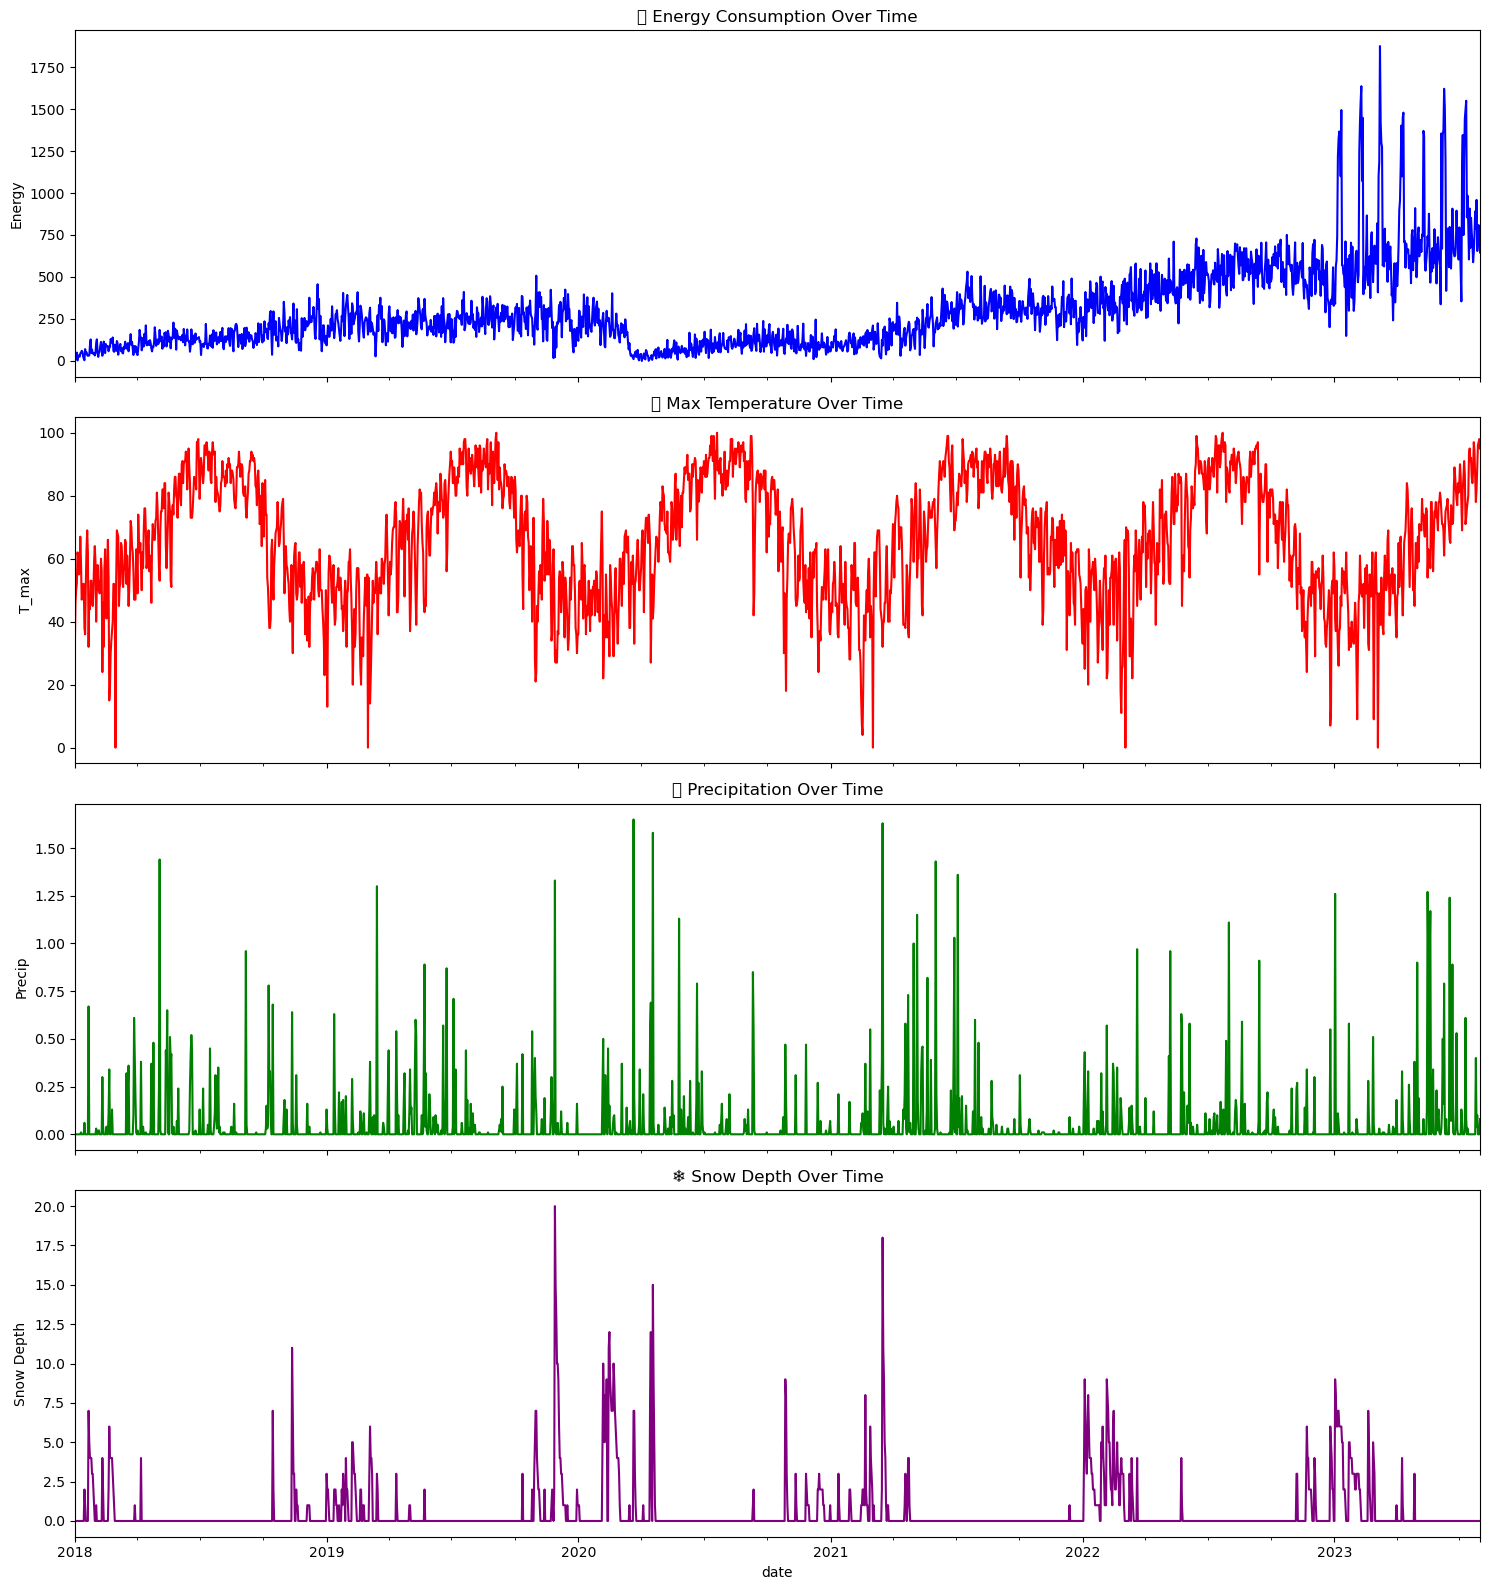

In [22]:
#Step 1: Time Series Plots of Energy and Weather

import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("ev_energy_with_weather.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

# Set date as index
df.set_index('date', inplace=True)

# Plot time series
fig, axes = plt.subplots(4, 1, figsize=(15, 16), sharex=True)

df['energy'].plot(ax=axes[0], color='blue')
axes[0].set_title("🔋 Energy Consumption Over Time")
axes[0].set_ylabel("Energy")

df['t_max'].plot(ax=axes[1], color='red')
axes[1].set_title("🌡️ Max Temperature Over Time")
axes[1].set_ylabel("T_max")

df['precip'].plot(ax=axes[2], color='green')
axes[2].set_title("🌧️ Precipitation Over Time")
axes[2].set_ylabel("Precip")

df['snow_depth'].plot(ax=axes[3], color='purple')
axes[3].set_title("❄️ Snow Depth Over Time")
axes[3].set_ylabel("Snow Depth")

plt.tight_layout()
plt.show()


c:\Users\KHALIL\anaconda3\envs\evforecast\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


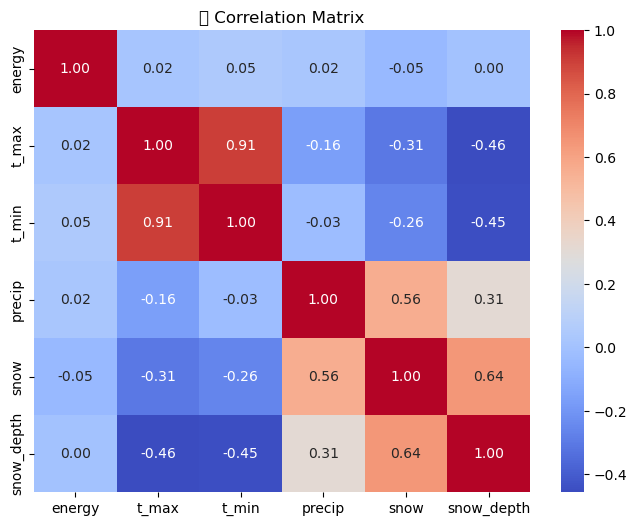

In [23]:
#Step 2: Correlation Analysis

import seaborn as sns

# Correlation matrix of numeric columns
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("📉 Correlation Matrix")
plt.show()

🔍 Interpretation Highlights from the Correlation Matrix:
✅ Strong Relationships ( > 0.6 or < -0.6):
t_max ↔ t_min: +0.91 → Expected, since daily max and min temperatures are naturally related.

snow ↔ snow_depth: +0.64 → Heavier snowfall tends to increase snow depth.

precip ↔ snow: +0.56 → Suggests some overlap in days with precipitation and snowfall.

📉 Weak/No Correlation with energy:
energy ↔ t_max: +0.02

energy ↔ t_min: +0.05

energy ↔ precip: +0.02

energy ↔ snow: −0.05

energy ↔ snow_depth: 0.00

💡 Insight: Weather variables show very weak linear correlation with energy consumption. This doesn't mean there's no relationship—just that it's not linear. Nonlinear models (e.g., decision trees, LSTM, or neural networks) might detect more subtle patterns.

In [26]:
!pip3 install statsmodels


   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   ------ --------------------------------- 1.6/9.7 MB 12.0 MB/s eta 0:00:01
   ------------- -------------------------- 3.1/9.7 MB 8.8 MB/s eta 0:00:01
   ------------------ --------------------- 4.5/9.7 MB 8.4 MB/s eta 0:00:01
   ------------------------ --------------- 6.0/9.7 MB 7.9 MB/s eta 0:00:01
   ----------------------------- ---------- 7.1/9.7 MB 7.4 MB/s eta 0:00:01
   ------------------------------- -------- 7.6/9.7 MB 6.6 MB/s eta 0:00:01
   ---------------------------------- ----- 8.4/9.7 MB 6.0 MB/s eta 0:00:01
   ------------------------------------ --- 8.9/9.7 MB 5.6 MB/s eta 0:00:01
   ---------------------------------------- 9.7/9.7 MB 5.3 MB/s eta 0:00:00

   ---------------------------------------- 0/2 [patsy]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   

c:\Users\KHALIL\anaconda3\envs\evforecast\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


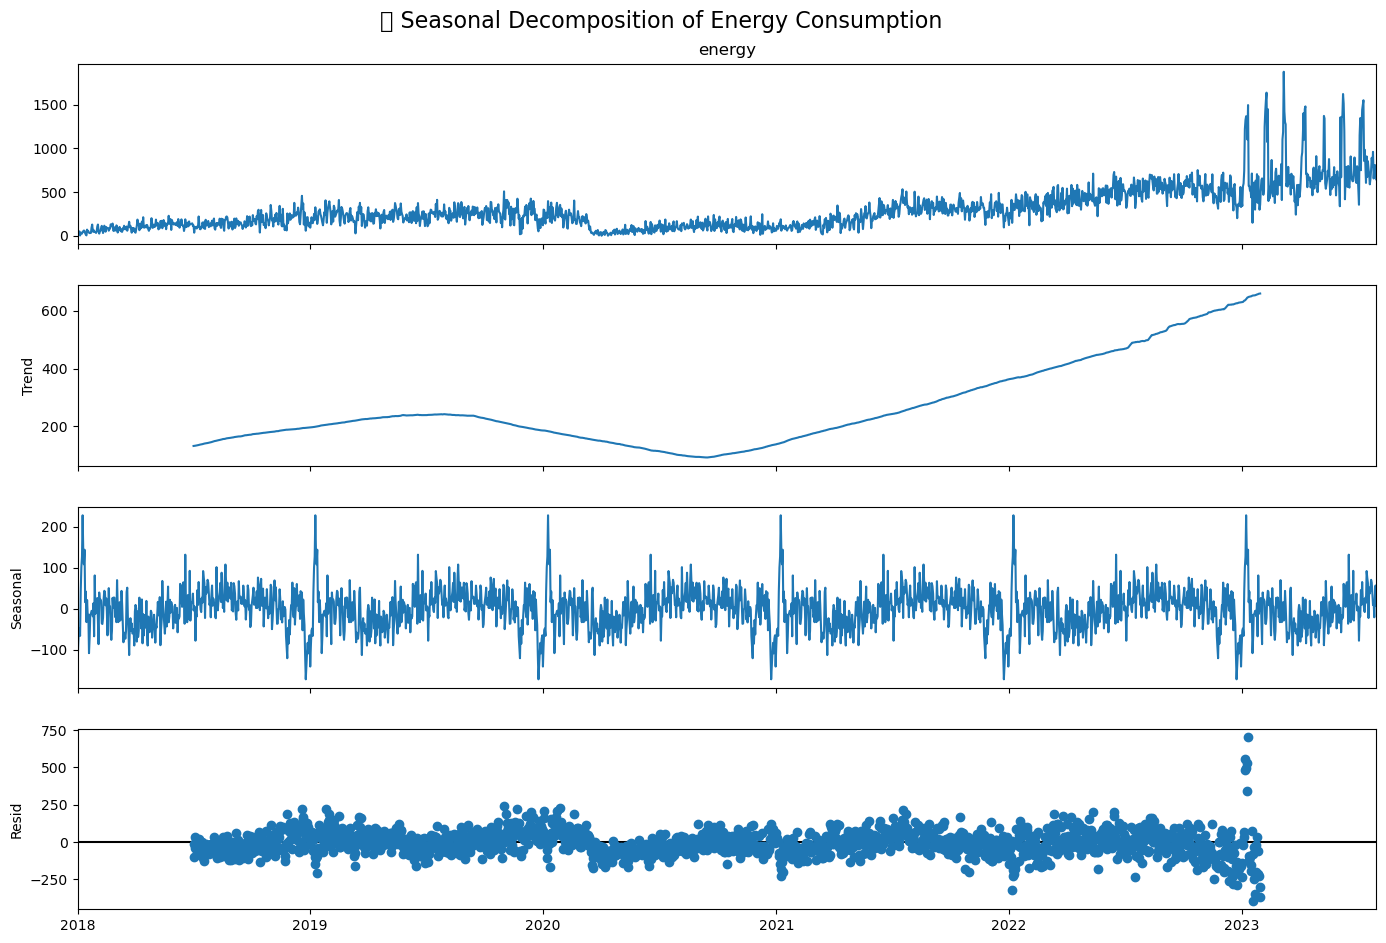

In [27]:
#Step 3: Seasonal Decomposition of Energy

import statsmodels.api as sm

# Seasonal decomposition (1 year = ~365 days)
decomposition = sm.tsa.seasonal_decompose(df['energy'], model='additive', period=365)

# Plot decomposition
fig = decomposition.plot()
fig.set_size_inches(15, 10)
plt.suptitle("📦 Seasonal Decomposition of Energy Consumption", fontsize=16)
plt.show()


In [28]:
#Add Time-Based Features

df['is_weekend'] = (df.index.dayofweek >= 5).astype(int)
df['day_of_week'] = df.index.dayofweek
df['month'] = df.index.month
df['is_winter'] = df['month'].isin([12, 1, 2]).astype(int)

In [30]:
#Weather-Derived Feature Captures daily temperature variation, which may influence EV energy demand.

df['temp_range'] = df['t_max'] - df['t_min']


In [31]:
df.head()

,energy,t_max,t_min,precip,snow,snow_depth,is_weekend,day_of_week,month,is_winter,temp_range
date,,,,,,,,,,,
2018-01-01,6.504,30,12,0.0,0.0,0,0,0,1,1,18
2018-01-02,17.527,46,12,0.0,0.0,0,0,1,1,1,34
2018-01-03,11.227,50,20,0.0,0.0,0,0,2,1,1,30
2018-01-04,49.748,52,24,0.0,0.0,0,0,3,1,1,28
2018-01-05,2.956,62,25,0.0,0.0,0,0,4,1,1,37


In [32]:
#Lag and Rolling Features

df['lag_1_energy'] = df['energy'].shift(1)
df['rolling_energy_7d'] = df['energy'].rolling(window=7).mean().shift(1)

In [33]:
df.head()

,energy,t_max,t_min,precip,snow,snow_depth,is_weekend,day_of_week,month,is_winter,temp_range,lag_1_energy,rolling_energy_7d
date,,,,,,,,,,,,,
2018-01-01,6.504,30,12,0.0,0.0,0,0,0,1,1,18,NaN,NaN
2018-01-02,17.527,46,12,0.0,0.0,0,0,1,1,1,34,6.504,NaN
2018-01-03,11.227,50,20,0.0,0.0,0,0,2,1,1,30,17.527,NaN
2018-01-04,49.748,52,24,0.0,0.0,0,0,3,1,1,28,11.227,NaN
2018-01-05,2.956,62,25,0.0,0.0,0,0,4,1,1,37,49.748,NaN
